# Data Quality Assessment

## Objective

This notebook performs a comprehensive Data Quality Assessment (DQA) of the retail loan portfolio used for IFRS 9 Expected Credit Loss (ECL) model development. The objective is to assess whether the dataset is complete, accurate, consistent, and suitable for downstream modelling activities, including Probability of Default (PD), Loss Given Default (LGD), and Exposure at Default (EAD).

## Analysis Overview

The assessment includes:

- Missing value analysis
- Duplicate record detection
- Validation of business rules and impossible values
- Distribution and extreme value assessment
- Variable variability assessment
- Correlation analysis

## Deliverables

The outputs of this notebook include:

- Data quality findings 
- Recommended cleaning actions



> **Note:** This notebook focuses on identifying and documenting data quality characteristics. Business judgement is applied when interpreting findings, as certain characteristics (e.g., conditional missing values, rare-event variables, and highly skewed financial variables) are expected in retail lending data and do not necessarily indicate poor data quality.

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [29]:
RAW_DATA = "../data/loan_raw.csv"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [30]:
df = pd.read_csv(RAW_DATA)

print(df.shape)

df.head()

(10000, 55)


,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,0,38.0,2001,6,28,10,70795,38767,0,0,38.0,0,1250,2,5,5.0,10,0.0,0,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar-18,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.0,14,0.0,0,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb-18,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,0,28.0,2006,4,31,10,24193,16000,0,0,28.0,0,432,1,13,7.0,10,0.0,0,3,4300,14,8,6,0,93.5,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb-18,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.0,4,0.0,0,2,19400,3,3,2,0,100.0,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan-18,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.0,16,0.0,0,10,32700,20,15,13,0,100.0,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar-18,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [31]:
overview = pd.DataFrame({

    "Metric":[
        "Rows",
        "Columns",
        "Numeric Variables",
        "Categorical Variables",
        "Memory Usage (MB)"
    ],

    "Value":[
        len(df),
        df.shape[1],
        len(df.select_dtypes(include=np.number).columns),
        len(df.select_dtypes(exclude=np.number).columns),
        round(df.memory_usage().sum()/1024**2,2)
    ]

})

overview

,Metric,Value
0,Rows,10000.0
1,Columns,55.0
2,Numeric Variables,42.0
3,Categorical Variables,13.0
4,Memory Usage (MB),4.2


In [32]:
datatype_summary = pd.DataFrame({

    "Variable":df.columns,

    "Data Type":df.dtypes.astype(str)

})

datatype_summary.head()

,Variable,Data Type
emp_title,emp_title,object
emp_length,emp_length,float64
state,state,object
homeownership,homeownership,object
annual_income,annual_income,float64


In [33]:
missing = pd.DataFrame({

    "Missing Count":df.isna().sum(),

    "Missing Percent":round(df.isna().mean()*100,2)

})

missing = missing.sort_values(
    "Missing Percent",
    ascending=False
)

missing

,Missing Count,Missing Percent
verification_income_joint,8545,85.45
debt_to_income_joint,8505,85.05
annual_income_joint,8505,85.05
months_since_90d_late,7715,77.15
months_since_last_delinq,5658,56.58
months_since_last_credit_inquiry,1271,12.71
emp_title,833,8.33
emp_length,817,8.17
num_accounts_120d_past_due,318,3.18
debt_to_income,24,0.24


In [34]:
joint_loans = df["application_type"] == "joint"

joint_variables = [
    "verification_income_joint",
    "debt_to_income_joint",
    "annual_income_joint"
]

for var in joint_variables:
    missing_pct = (
        df.loc[joint_loans, var]
          .isna()
          .mean() * 100
    )

    print(f"{var}: {missing_pct:.2f}% missing")

verification_income_joint: 2.68% missing
debt_to_income_joint: 0.00% missing
annual_income_joint: 0.00% missing


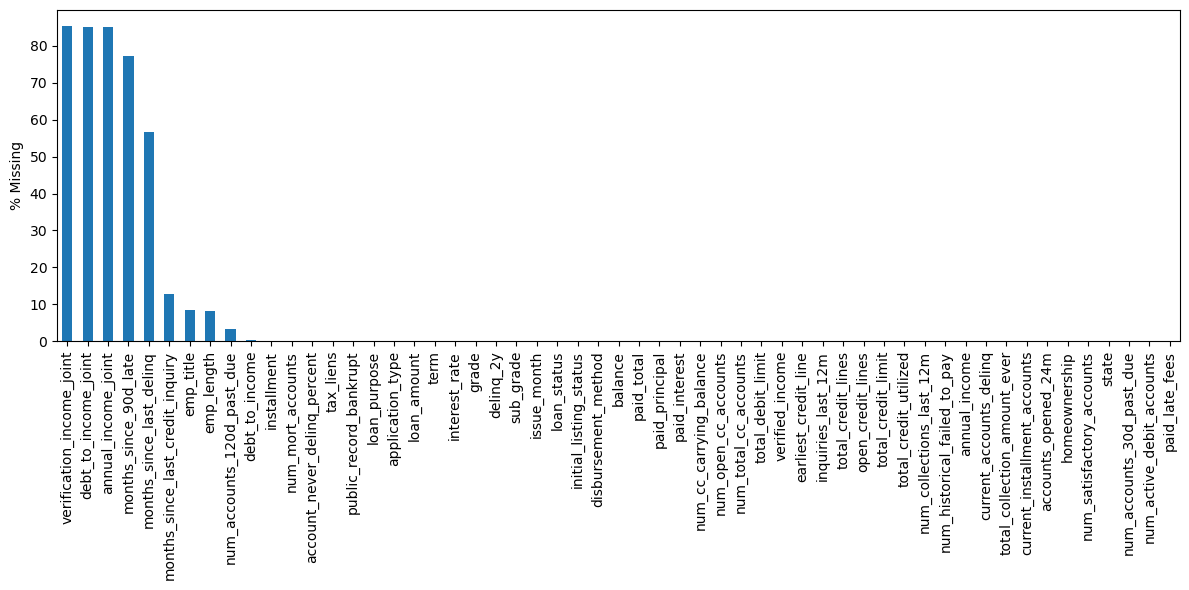

In [35]:
plt.figure(figsize=(12,6))

missing["Missing Percent"].plot(kind="bar")

plt.ylabel("% Missing")

plt.tight_layout()

plt.show()

In [36]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


In [37]:
validation_results = []

def add_validation_result(validation_name, failed_count, total_records, severity="Critical"):

    failed_pct = round(failed_count / total_records * 100, 2)

    if failed_count == 0:
        status = "Pass"
    else:
        status = "Review"

    validation_results.append({
        "Validation": validation_name,
        "Failed Records": failed_count,
        "Failed %": failed_pct,
        "Severity": severity,
        "Status": status
    })

In [38]:
failed = (df["loan_amount"] <= 0).sum()

add_validation_result(
    "Loan Amount > 0",
    failed,
    len(df)
)

failed = (df["annual_income"] < 0).sum()

add_validation_result(
    "Annual Income ≥ 0",
    failed,
    len(df)
)

failed = ((df["interest_rate"] < 0)).sum()

add_validation_result(
    "Interest Rate Between 0 and 100",
    failed,
    len(df)
)

failed = (df["installment"] <= 0).sum()

add_validation_result(
    "Installment > 0",
    failed,
    len(df)
)

failed = (df["balance"] < 0).sum()

add_validation_result(
    "Balance ≥ 0",
    failed,
    len(df)
)

failed = (df["paid_total"] < 0).sum()

add_validation_result(
    "Paid Total ≥ 0",
    failed,
    len(df)
)

failed = (df["paid_principal"] < 0).sum()

add_validation_result(
    "Paid Principal ≥ 0",
    failed,
    len(df)
)

failed = (df["paid_interest"] < 0).sum()

add_validation_result(
    "Paid Interest ≥ 0",
    failed,
    len(df)
)

failed = (df["paid_late_fees"] < 0).sum()

add_validation_result(
    "Paid Late Fees ≥ 0",
    failed,
    len(df)
)

In [39]:
failed = (
    df["open_credit_lines"] >
    df["total_credit_lines"]
).sum()

add_validation_result(
    "Open Credit Lines ≤ Total Credit Lines",
    failed,
    len(df),
    severity="Medium"
)

failed = (
    df["total_credit_utilized"] >
    df["total_credit_limit"]
).sum()

add_validation_result(
    "Credit Utilized ≤ Credit Limit",
    failed,
    len(df),
    severity="Medium"
)

failed = (
    df["num_open_cc_accounts"] >
    df["num_total_cc_accounts"]
).sum()

add_validation_result(
    "Open CC Accounts ≤ Total CC Accounts",
    failed,
    len(df),
    severity="Medium"
)

failed = (
    df["num_cc_carrying_balance"] >
    df["num_open_cc_accounts"]
).sum()

add_validation_result(
    "CC Carrying Balance Accounts ≤ Open CC Accounts",
    failed,
    len(df),
    severity="Medium"
)

In [40]:
joint = df["application_type"] == "joint"

failed = (
    joint &
    df["annual_income_joint"].isna()
).sum()

add_validation_result(
    "Joint Annual Income Populated",
    failed,
    len(df),
    severity="Medium"
)

In [41]:
validation_summary = pd.DataFrame(validation_results)

validation_summary

,Validation,Failed Records,Failed %,Severity,Status
0,Loan Amount > 0,0,0.00,Critical,Pass
1,Annual Income ≥ 0,0,0.00,Critical,Pass
2,Interest Rate Between 0 and 100,0,0.00,Critical,Pass
3,Installment > 0,0,0.00,Critical,Pass
4,Balance ≥ 0,0,0.00,Critical,Pass
5,Paid Total ≥ 0,0,0.00,Critical,Pass
6,Paid Principal ≥ 0,0,0.00,Critical,Pass
7,Paid Interest ≥ 0,0,0.00,Critical,Pass
8,Paid Late Fees ≥ 0,0,0.00,Critical,Pass
9,Open Credit Lines ≤ Total Credit Lines,0,0.00,Medium,Pass


In [42]:
numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_cols:

    q1 = df[col].quantile(.25)

    q3 = df[col].quantile(.75)

    iqr = q3-q1

    lower = q1-1.5*iqr

    upper = q3+1.5*iqr

    outliers=((df[col]<lower)|(df[col]>upper)).sum()

    outlier_summary.append([col,outliers])

outlier_summary = pd.DataFrame(

    outlier_summary,

    columns=["Variable","Outliers"]

)

outlier_summary

,Variable,Outliers
0,emp_length,0
1,annual_income,508
2,debt_to_income,221
3,annual_income_joint,68
4,debt_to_income_joint,0
5,delinq_2y,1424
6,months_since_last_delinq,4
7,earliest_credit_line,313
8,inquiries_last_12m,349
9,total_credit_lines,223


In [43]:
numeric_cols = df.select_dtypes(include="number").columns

In [44]:
distribution_summary = []

for col in numeric_cols:

    series = df[col].dropna()

    if len(series) == 0:
        continue

    missing_pct = df[col].isna().mean() * 100

    skewness = series.skew()

    zero_pct = (series == 0).mean() * 100

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_pct = (
        ((series < lower) | (series > upper)).mean()
    ) * 100

    distribution_summary.append({
        "Variable": col,
        "IQR Outlier %": round(outlier_pct, 2),
        "Skewness": round(skewness, 2),
        "Zero %": round(zero_pct, 2),   
        "Missing %": round(missing_pct, 2)
    })

distribution_summary = pd.DataFrame(distribution_summary)

In [45]:
distribution_summary = distribution_summary.sort_values(
    by=["IQR Outlier %","Skewness"],
    ascending=[False, False]
)

distribution_summary

,Variable,IQR Outlier %,Skewness,Zero %,Missing %
5,delinq_2y,14.24,5.87,85.76,0.00
14,num_historical_failed_to_pay,14.14,44.04,85.86,0.00
17,total_collection_amount_ever,13.65,74.58,86.35,0.00
32,public_record_bankrupt,12.15,2.53,87.85,0.00
30,account_never_delinq_percent,8.83,-2.58,0.00,0.00
39,paid_principal,8.31,6.17,0.15,0.00
18,current_installment_accounts,8.15,2.85,14.14,0.00
38,paid_total,6.19,5.85,0.15,0.00
12,total_credit_utilized,5.68,4.10,0.28,0.00
25,total_debit_limit,5.52,2.56,1.35,0.00


In [46]:
HIGH_SKEW = 2
HIGH_ZERO = 95
HIGH_OUTLIER = 10

In [47]:
high_skew = distribution_summary.loc[
    distribution_summary["Skewness"].abs() > HIGH_SKEW,
    "Variable"
].tolist()

zero_inflated = distribution_summary.loc[
    distribution_summary["Zero %"] > HIGH_ZERO,
    "Variable"
].tolist()

heavy_tailed = distribution_summary.loc[
    distribution_summary["IQR Outlier %"] > HIGH_OUTLIER,
    "Variable"
].tolist()

business_critical = [

    "annual_income",

    "loan_amount",

    "balance",

    "interest_rate",

    "debt_to_income"

]

In [48]:
plot_variables = sorted(
    set(
        high_skew +
        zero_inflated +
        heavy_tailed +
        business_critical
    )
)

print(plot_variables)

['account_never_delinq_percent', 'annual_income', 'annual_income_joint', 'balance', 'current_accounts_delinq', 'current_installment_accounts', 'debt_to_income', 'delinq_2y', 'inquiries_last_12m', 'interest_rate', 'loan_amount', 'num_accounts_120d_past_due', 'num_accounts_30d_past_due', 'num_collections_last_12m', 'num_historical_failed_to_pay', 'paid_late_fees', 'paid_principal', 'paid_total', 'public_record_bankrupt', 'tax_liens', 'total_collection_amount_ever', 'total_credit_limit', 'total_credit_utilized', 'total_debit_limit']


In [49]:
import matplotlib.pyplot as plt

def plot_distribution(df, variable):

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(12,4)
    )

    # Histogram

    ax[0].hist(
        df[variable].dropna(),
        bins=30
    )

    ax[0].set_title(f"{variable}\nHistogram")

    # Boxplot

    ax[1].boxplot(
        df[variable].dropna(),
        vert=False
    )

    ax[1].set_title(f"{variable}\nBoxplot")

    plt.tight_layout()

    plt.show()

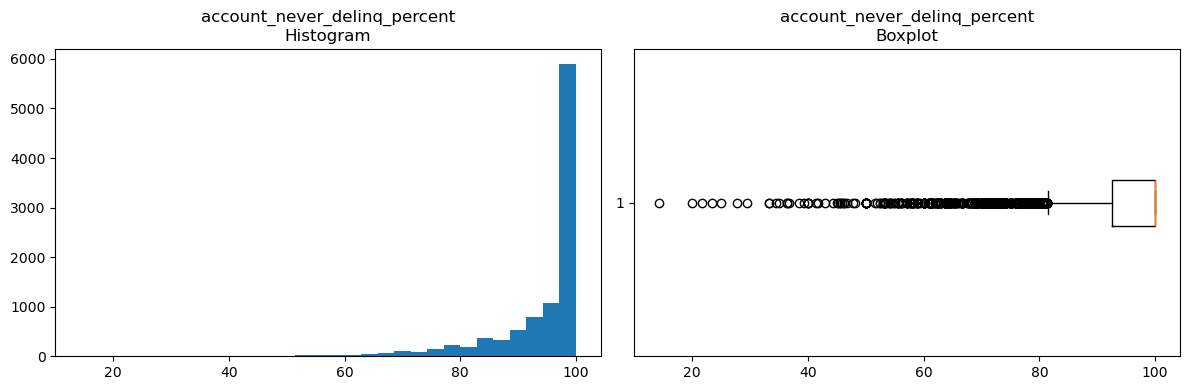

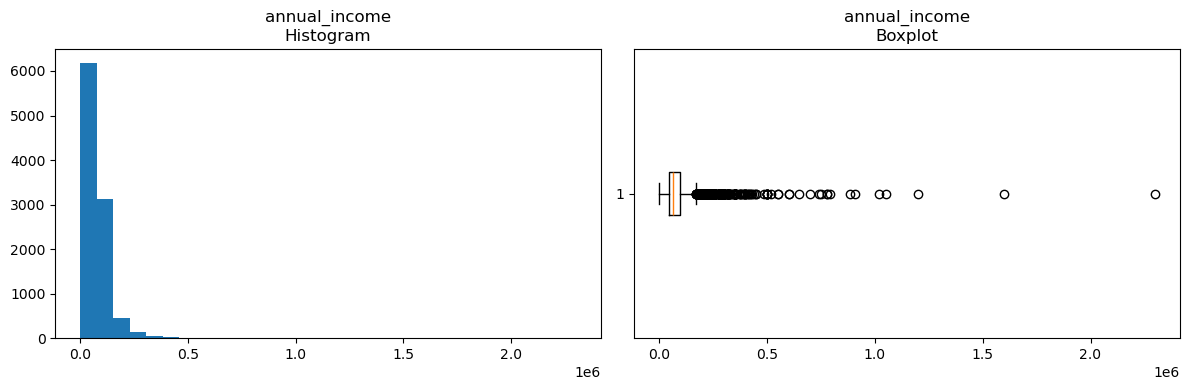

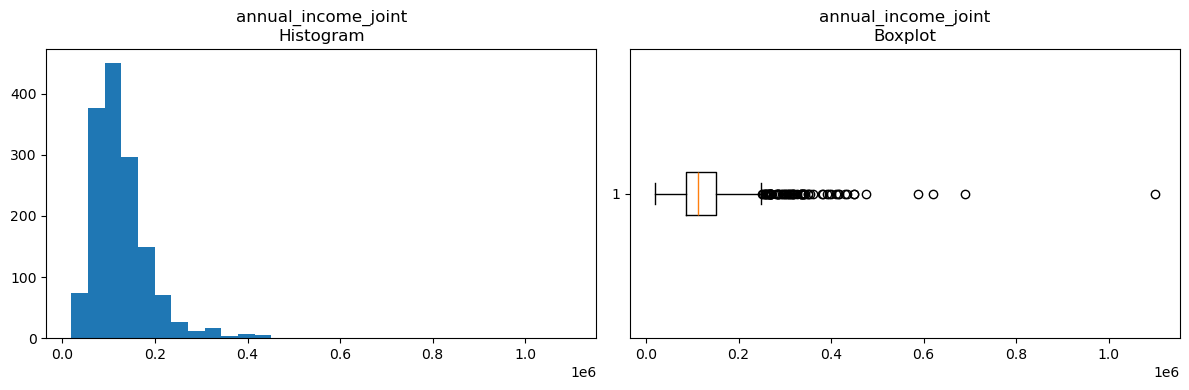

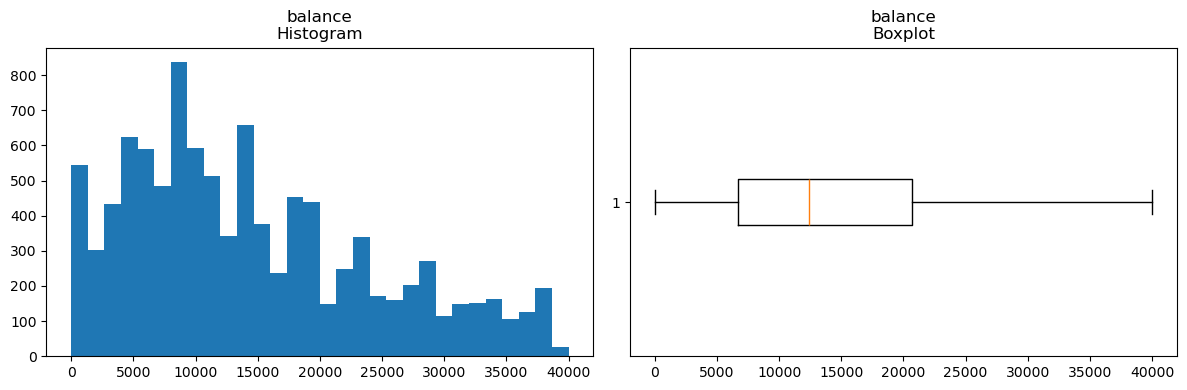

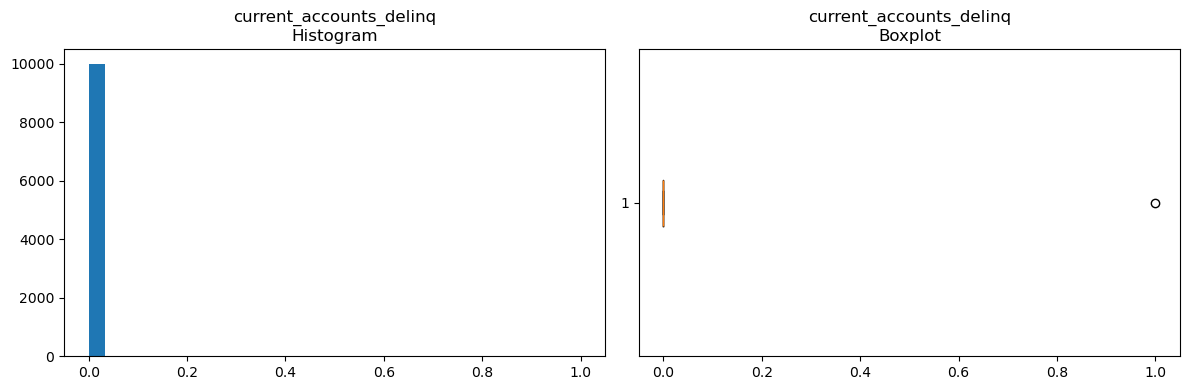

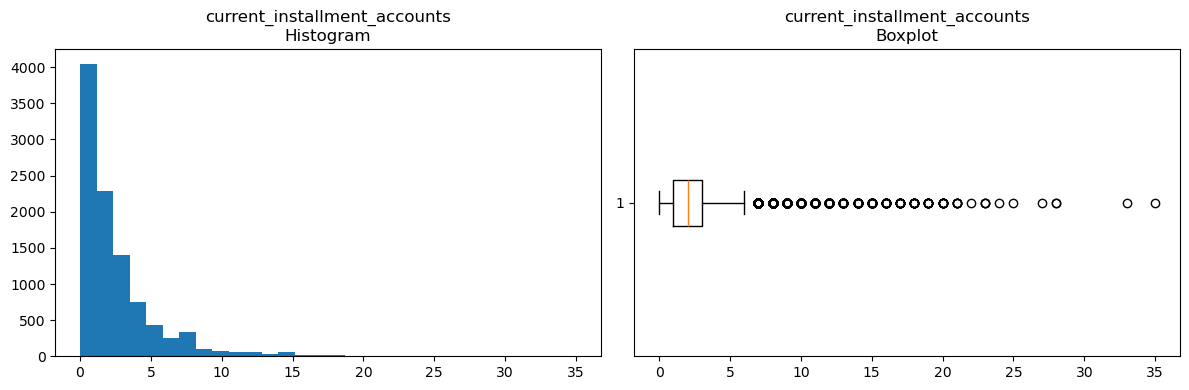

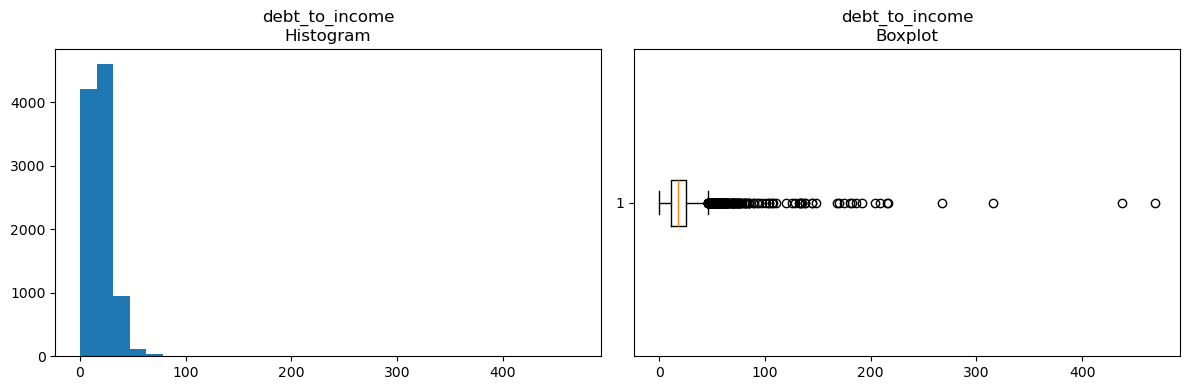

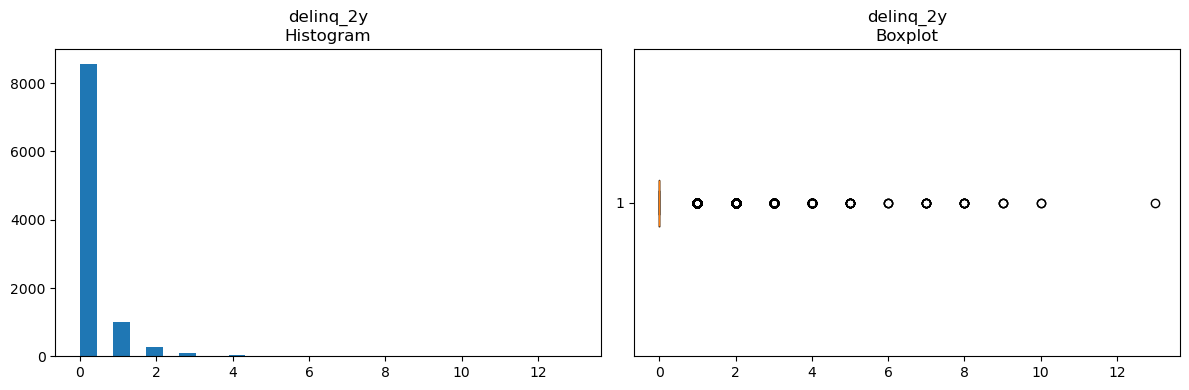

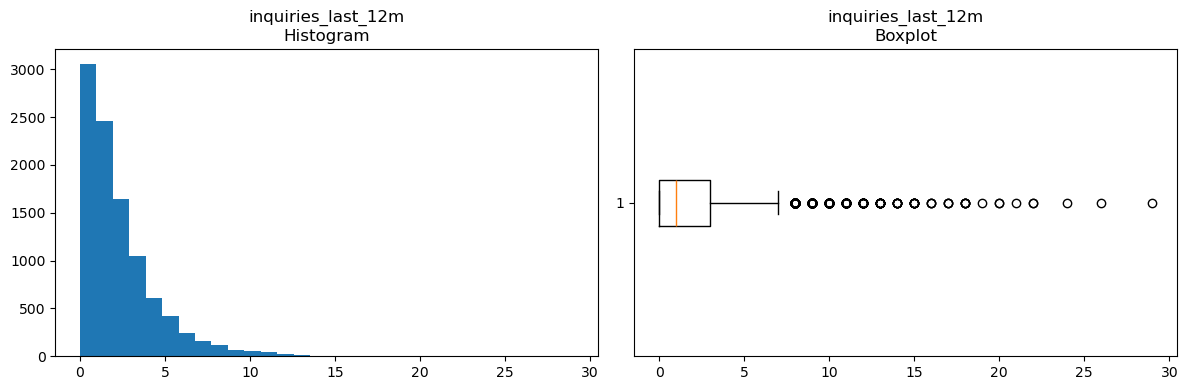

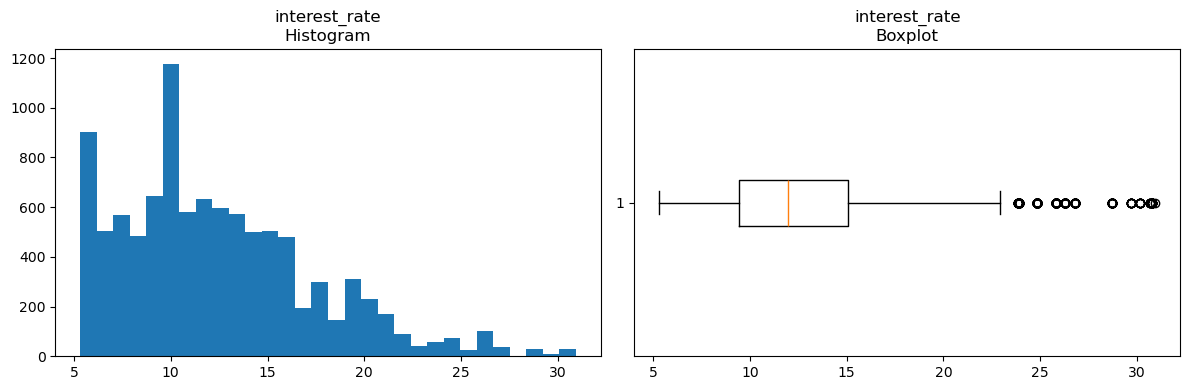

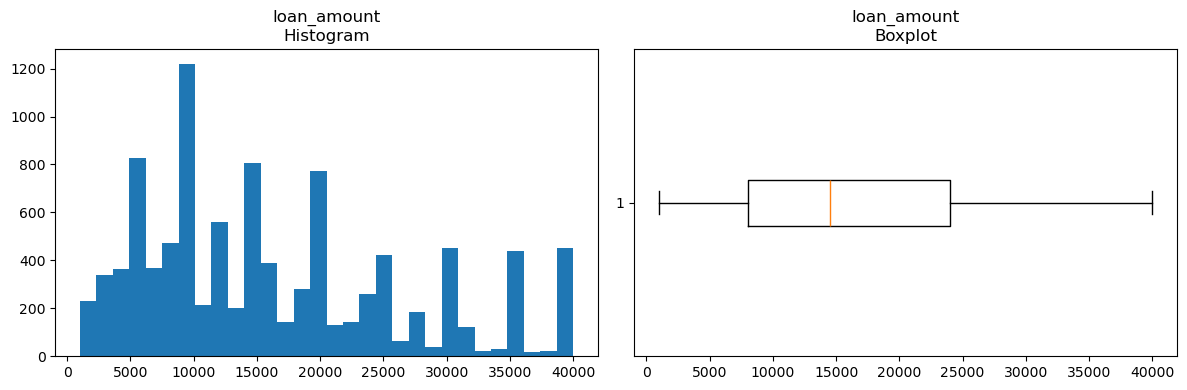

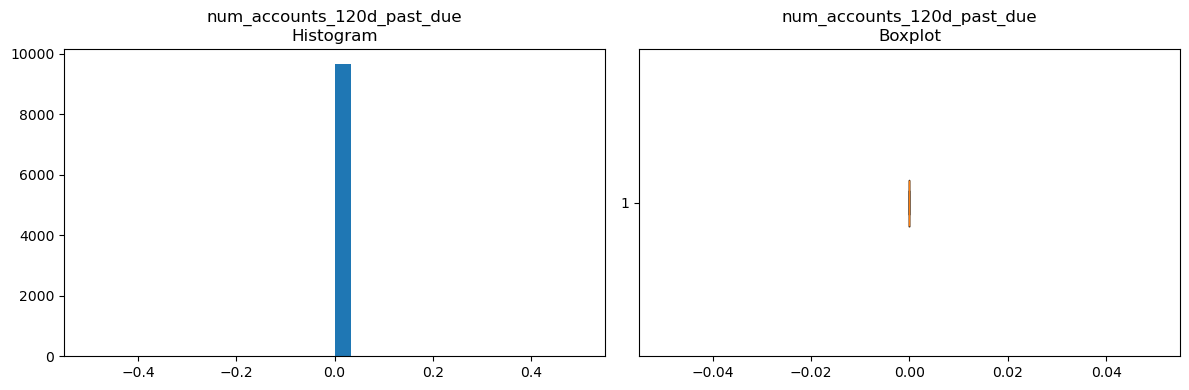

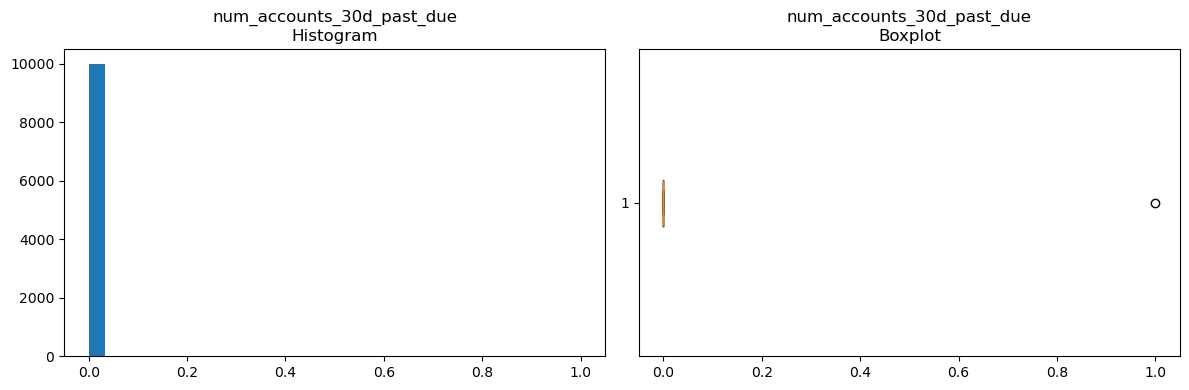

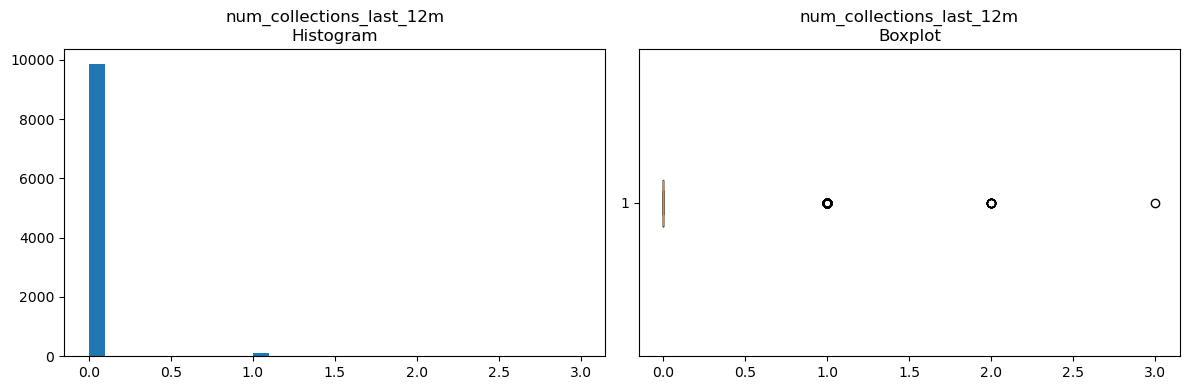

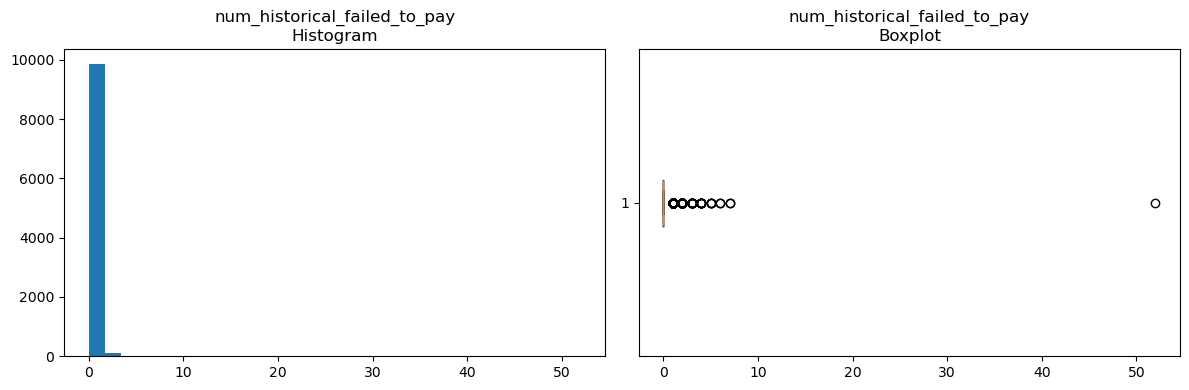

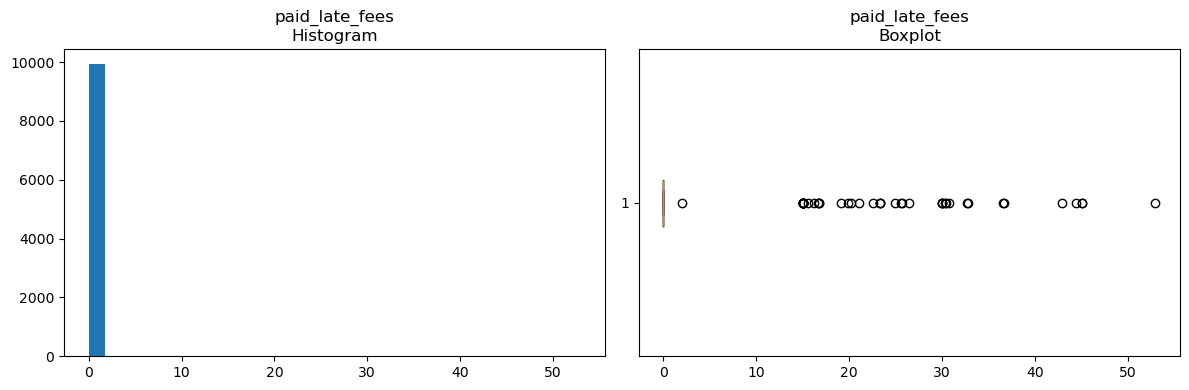

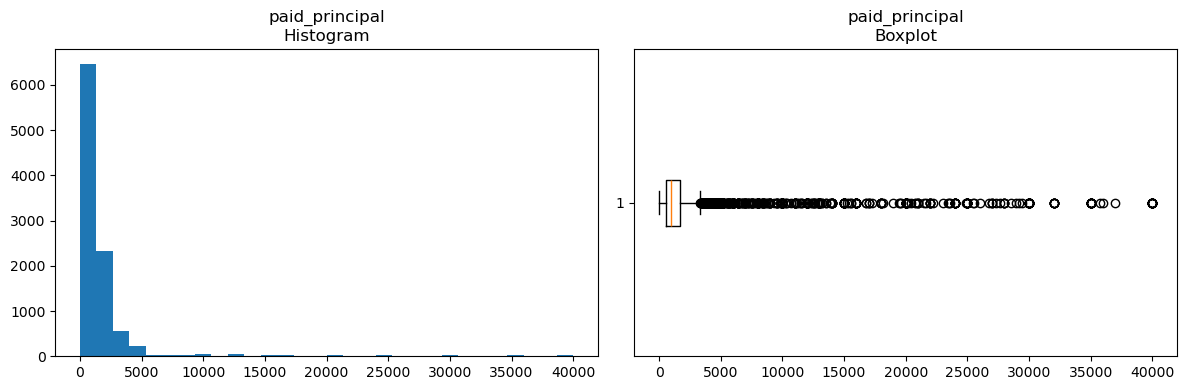

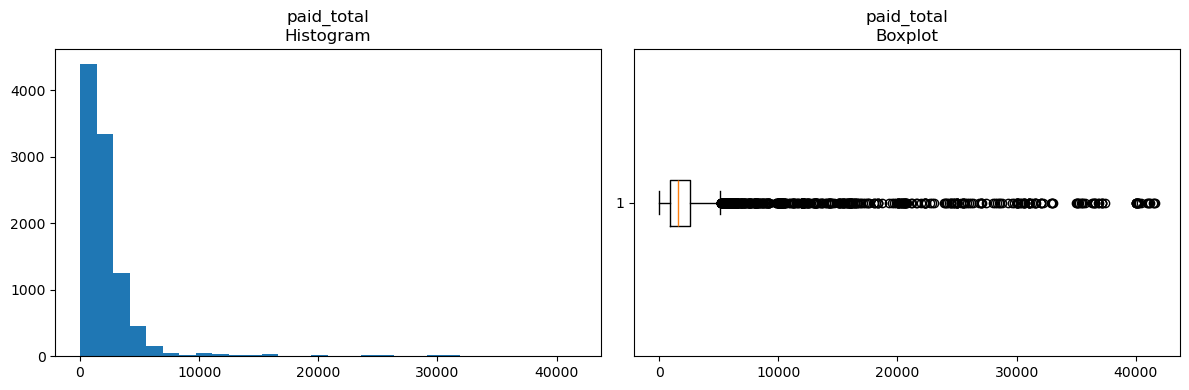

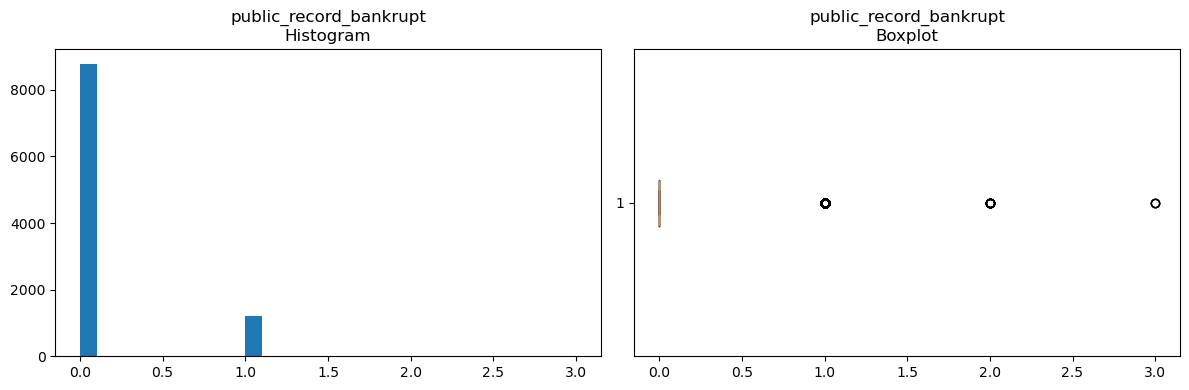

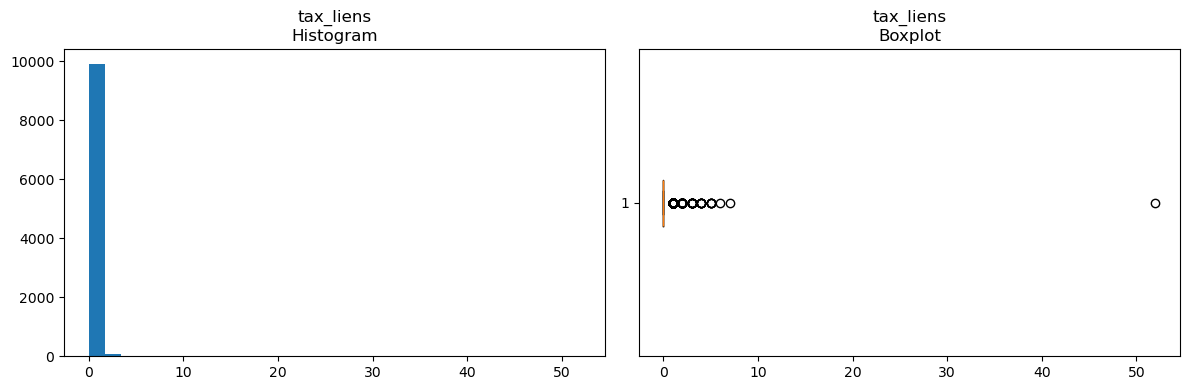

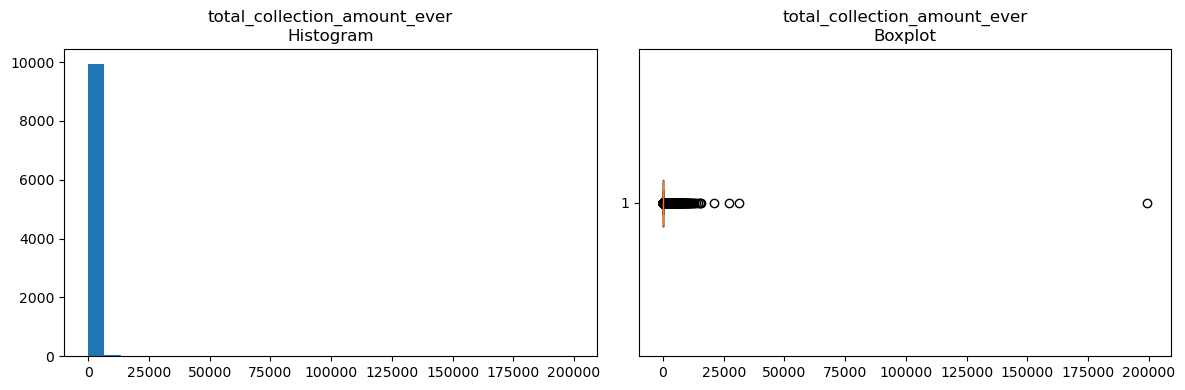

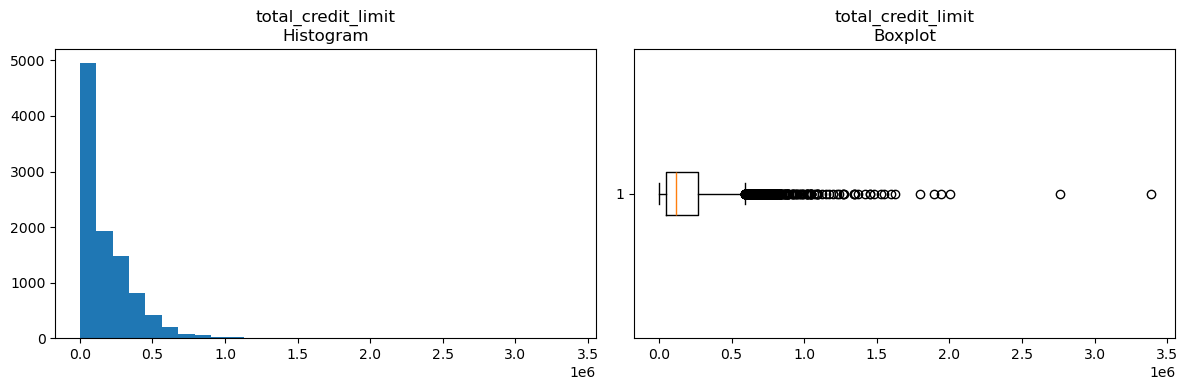

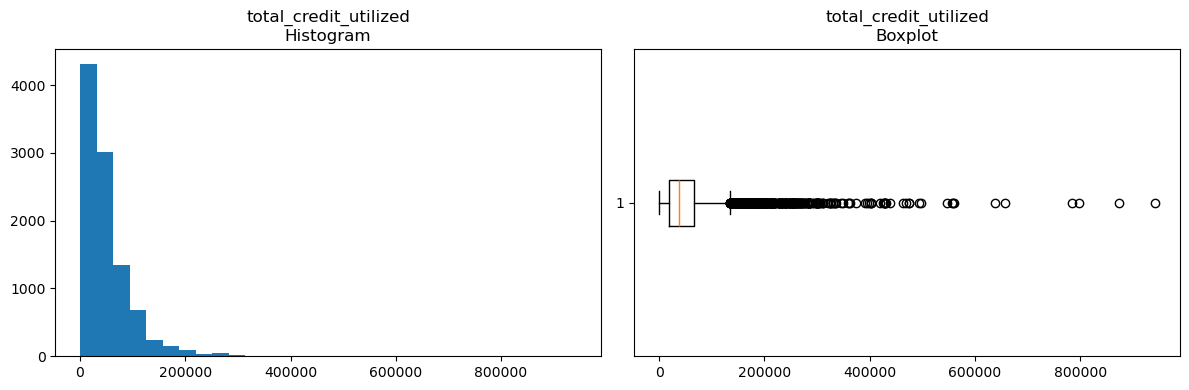

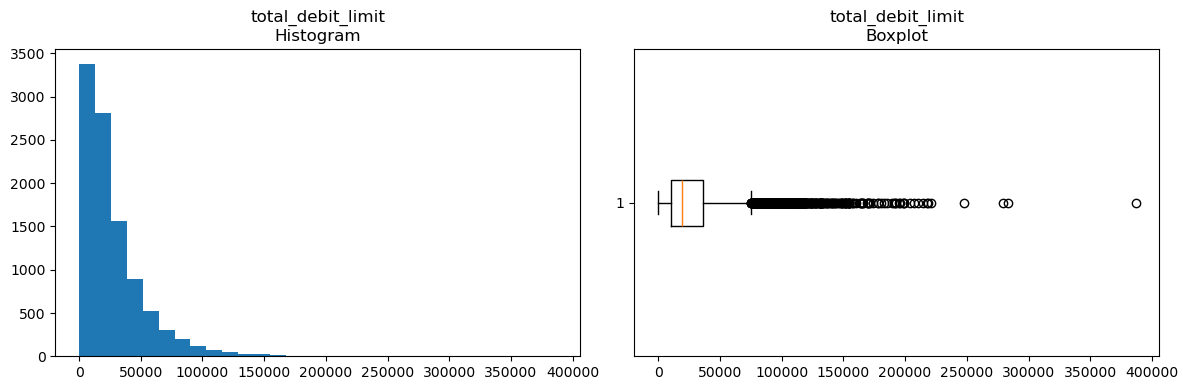

In [50]:
for var in plot_variables:

    plot_distribution(df, var)
    

In [51]:
numeric_cols = df.select_dtypes(include="number").columns

results = []

for col in numeric_cols:
    data = df[col].dropna()
    unique_values = data.nunique()
    most_common_pct = (
        data.value_counts(normalize=True)
            .iloc[0] * 100
    )
    std = data.std()
    variance = data.var()

    results.append({
        "Variable": col,
        "Unique Values": unique_values,
        "Most Common Value %": round(most_common_pct, 2),
        "Standard Deviation": round(std, 2),
        "Variance": round(variance, 2)
    })

variability_summary = pd.DataFrame(results)

variability_summary

,Variable,Unique Values,Most Common Value %,Standard Deviation,Variance
0,emp_length,11,36.28,3.70,1.372000e+01
1,annual_income,1463,3.83,64734.29,4.190528e+09
2,debt_to_income,3673,0.28,15.00,2.251500e+02
3,annual_income_joint,596,2.07,70168.38,4.923601e+09
4,debt_to_income_joint,1189,0.33,8.05,6.488000e+01
5,delinq_2y,12,85.76,0.68,4.700000e-01
6,months_since_last_delinq,97,2.00,21.63,4.680700e+02
7,earliest_credit_line,53,7.68,7.80,6.077000e+01
8,inquiries_last_12m,26,30.60,2.38,5.670000e+00
9,total_credit_lines,78,3.79,11.89,1.412600e+02


In [52]:
def assess_variability(row):

    if row["Unique Values"] <= 2:
        return "Near-zero variance"

    elif row["Most Common Value %"] >= 95:
        return "Highly concentrated"

    elif row["Variance"] == 0:
        return "Constant"

    else:
        return "Sufficient variability"


variability_summary["Assessment"] = (
    variability_summary
        .apply(assess_variability, axis=1)
)

variability_summary

,Variable,Unique Values,Most Common Value %,Standard Deviation,Variance,Assessment
0,emp_length,11,36.28,3.70,1.372000e+01,Sufficient variability
1,annual_income,1463,3.83,64734.29,4.190528e+09,Sufficient variability
2,debt_to_income,3673,0.28,15.00,2.251500e+02,Sufficient variability
3,annual_income_joint,596,2.07,70168.38,4.923601e+09,Sufficient variability
4,debt_to_income_joint,1189,0.33,8.05,6.488000e+01,Sufficient variability
5,delinq_2y,12,85.76,0.68,4.700000e-01,Sufficient variability
6,months_since_last_delinq,97,2.00,21.63,4.680700e+02,Sufficient variability
7,earliest_credit_line,53,7.68,7.80,6.077000e+01,Sufficient variability
8,inquiries_last_12m,26,30.60,2.38,5.670000e+00,Sufficient variability
9,total_credit_lines,78,3.79,11.89,1.412600e+02,Sufficient variability


In [53]:
corr = df[numeric_cols].corr()

corr

,emp_length,annual_income,debt_to_income,annual_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_amount,term,interest_rate,installment,balance,paid_total,paid_principal,paid_interest,paid_late_fees
emp_length,1.000000,0.096469,0.026157,0.071282,0.002103,0.008242,0.028790,-0.234408,0.003753,0.133472,0.067415,0.147594,0.019694,-0.015729,0.029997,0.077553,-0.011075,0.007772,-0.099357,0.027457,0.008758,0.067049,NaN,-0.011075,0.082499,0.095866,0.160848,0.115429,0.120279,0.209962,-0.000228,0.018134,0.030083,0.091255,0.056243,-0.029621,0.075981,0.086768,0.024246,0.018153,0.049517,0.001851
annual_income,0.096469,1.000000,-0.180445,0.724664,-0.179790,0.052236,-0.040392,-0.156001,0.090119,0.210163,0.176788,0.516703,0.406370,-0.008330,0.025976,0.002810,0.001665,-0.000080,0.096542,0.094446,-0.050009,0.176957,NaN,0.001665,0.156078,0.328861,0.123963,0.112329,0.125455,0.243188,-0.010542,0.047439,-0.030568,0.324665,0.044843,-0.099584,0.315693,0.280170,0.162005,0.141893,0.174154,-0.005318
debt_to_income,0.026157,-0.180445,1.000000,-0.047284,0.348912,-0.027517,0.034637,-0.089700,0.025388,0.198647,0.217078,0.075174,0.238155,-0.011200,-0.004146,0.024982,0.007342,0.019175,0.200470,0.067724,0.023670,0.217000,NaN,0.007342,0.147478,0.065328,0.128341,0.136041,0.189845,0.033365,0.076636,-0.008522,0.006560,0.056329,0.046490,0.141653,0.066408,0.065996,-0.003918,-0.020116,0.121160,-0.010110
annual_income_joint,0.071282,0.724664,-0.047284,1.000000,-0.215504,0.046276,-0.049124,-0.175325,0.082176,0.240166,0.187639,0.493295,0.390667,-0.006926,-0.040135,-0.066533,NaN,0.012387,0.101302,0.055102,-0.029969,0.188730,NaN,NaN,0.145090,0.365135,0.170414,0.128796,0.112621,0.239525,-0.011635,-0.006605,-0.047933,0.330607,0.017057,-0.165327,0.303795,0.302291,0.108933,0.092761,0.120788,-0.002689
debt_to_income_joint,0.002103,-0.179790,0.348912,-0.215504,1.000000,-0.029220,0.065376,-0.091637,0.029515,0.187683,0.243765,-0.001495,0.316672,-0.000144,-0.031514,0.031667,NaN,0.002116,0.231431,0.101720,-0.037858,0.243484,NaN,NaN,0.178986,0.025449,0.119194,0.152397,0.232790,-0.078316,0.054834,0.017887,-0.057415,0.045363,0.037234,0.266417,0.079405,0.055566,0.001389,-0.025166,0.177931,-0.028840
delinq_2y,0.008242,0.052236,-0.027517,0.046276,-0.029220,1.000000,-0.566551,-0.078109,0.003152,0.068040,0.013050,0.053373,0.001855,0.077680,-0.026574,-0.428286,0.026097,0.011577,0.005762,-0.062541,0.005850,0.012409,NaN,0.026097,-0.026848,-0.085512,0.060118,0.000471,-0.002676,0.063506,-0.444056,-0.005303,-0.044865,-0.033258,-0.025936,0.090456,-0.013724,-0.031440,-0.004490,-0.006857,0.017165,-0.009404
months_since_last_delinq,0.028790,-0.040392,0.034637,-0.049124,0.065376,-0.566551,1.000000,0.030064,0.022727,-0.014727,-0.002766,-0.061514,0.019946,-0.059018,0.039172,0.711232,-0.025090,-0.001114,0.022848,0.113642,-0.027598,-0.001780,NaN,-0.025090,0.009884,0.034657,-0.033579,-0.003882,0.006803,-0.045417,0.225440,0.008799,0.096420,0.029247,0.036953,-0.082930,0.008274,0.036517,-0.017350,-0.016431,-0.009362,0.005123
earliest_credit_line,-0.234408,-0.156001,-0.089700,-0.175325,-0.091637,-0.078109,0.030064,1.000000,0.042745,-0.294621,-0.174322,-0.231230,-0.140936,-0.000813,-0.031572,-0.019322,-0.018333,-0.018070,0.016580,0.024696,-0.010578,-0.172642,NaN,-0.018333,-0.128726,-0.239871,-0.310678,-0.184406,-0.167074,-0.287344,0.099086,-0.013752,-0.040181,-0.117749,-0.032736,0.103635,-0.100001,-

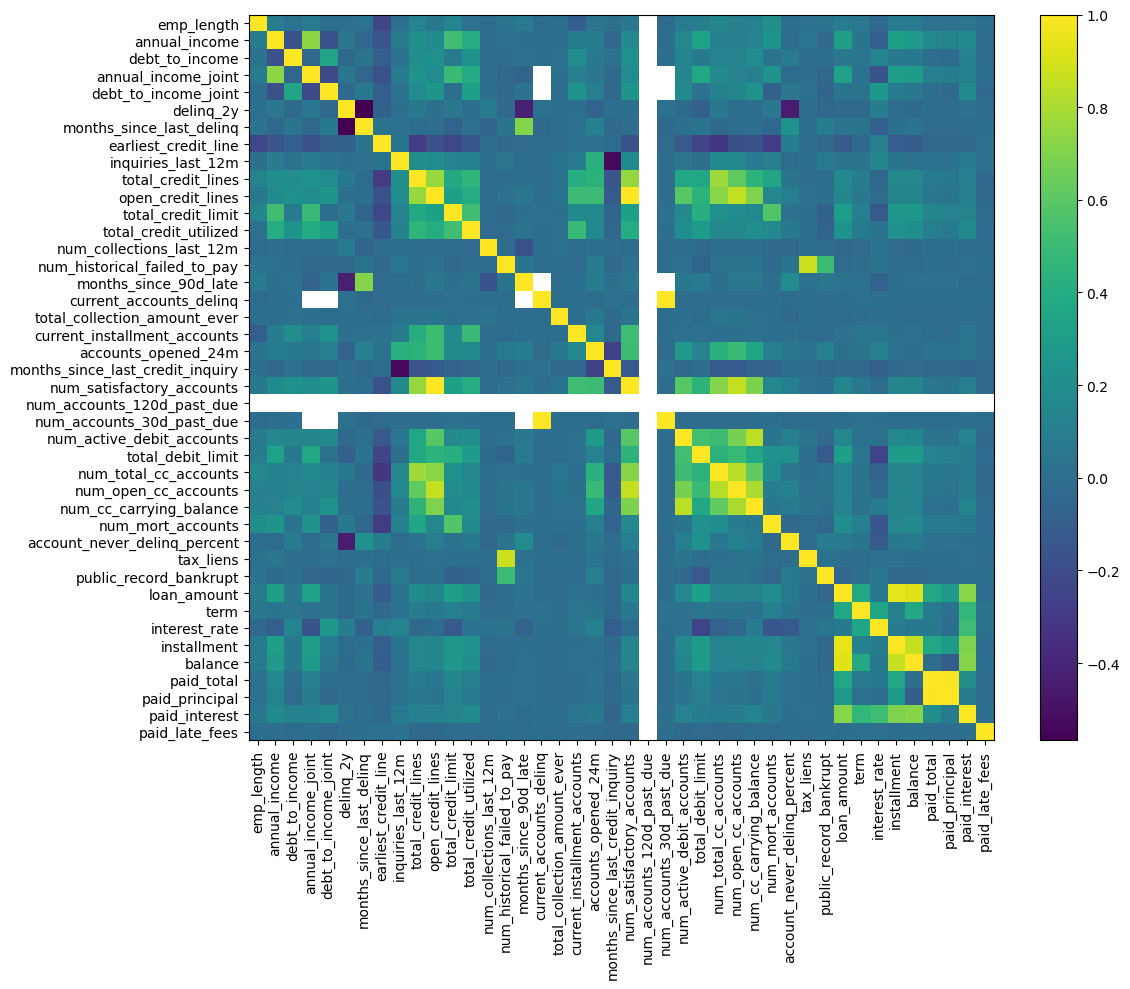

In [54]:
plt.figure(figsize=(12,10))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.tight_layout()

plt.show()